In [1]:
import numpy as np
from genmag_exact import limit_from_zero_pattern

# sim mat at t->infを計算(0or1の行列に）、正定値ならそこから厳密計算
D = np.load("/Users/kyokokusano/ResearchData_keep/dissim_Togashi/001_RDM.npy").copy()
np.fill_diagonal(D, 0.0)          # the raw file has 1 on nine diagonal entries
print(limit_from_zero_pattern(D.tolist()))

ZeroPatternLimit(limit=Fraction(362903, 10731), rank_at_infinity=93, size=93)


In [4]:
import numpy as np
from genmag_exact import arbitrary_precision

# 特定のtについてfloat以上の任意の桁数で数値計算する
D = np.load("/Users/kyokokusano/ResearchData_keep/dissim_Togashi/004_RDM.npy").copy()
np.fill_diagonal(D, 0.0)
for t in [2, 10, 20, 50, 120]:
    print(t, arbitrary_precision.genmag_at(D.tolist(), t, wanted_digits=15))

2 CertifiedValue(t=2.0, midpoint='28.4871140587724', radius=9.017140889153102e-16, accurate_digits=16.499579599037684, precision_bits=64, is_resolved=True)
10 CertifiedValue(t=10.0, midpoint='32.4241219617678', radius=4.1806761802266136e-32, accurate_digits=32.88962169431172, precision_bits=128, is_resolved=True)
20 CertifiedValue(t=20.0, midpoint='32.4251564340217', radius=1.0169417965063144e-27, accurate_digits=28.503585982710522, precision_bits=128, is_resolved=True)
50 CertifiedValue(t=50.0, midpoint='32.4251564809864', radius=2.759468187272154e-26, accurate_digits=27.070056688993677, precision_bits=256, is_resolved=True)
120 CertifiedValue(t=120.0, midpoint='32.4251564809864', radius=2.687689620338314e-44, accurate_digits=45.08150296652855, precision_bits=1024, is_resolved=True)


In [4]:
# 任意の桁数での数値計算を範囲のあるtで計算

grid = np.logspace(-2, 2.3, 260)
curve = arbitrary_precision.genmag_curve(D.tolist(), grid, wanted_digits=15, progress=True)
print(len(curve), max(c.precision_bits for c in curve), sum(not c.is_resolved for c in curve))

[260/260] t=199.5 2048 bits                                
260 2048 0


[260/260] t=199.5                                
[260/260] scanning t=199.5                       


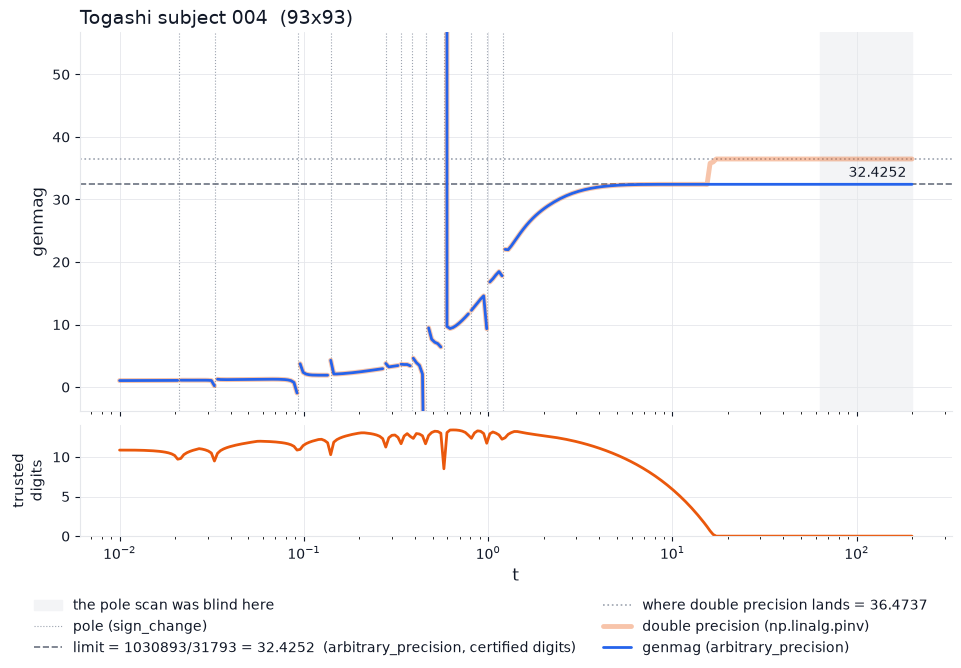

In [17]:
from qstr_dataset.profile_builder import magnitude_profile
from qstr_dataset.profile_plot import plot_magnitude_profile
import numpy as np
from pathlib import Path

# magnitude_profileで、自動で可能な精度高い方法の計算をすることでprofileのデータを得て、
# plot_magnitude_profileで、それを実際にプロットしている。

D = np.load("/Users/kyokokusano/ResearchData_keep/dissim_Togashi/004_RDM.npy").copy()
np.fill_diagonal(D, 0.0)
figpath = Path.cwd().parent.parent / "results/figures/profile_togashi_004.png"

result = magnitude_profile(D, symbolic_timeout_sec=0, progress=True)   # n=93 は symbolic を試さない
main_axes, trust_axes = plot_magnitude_profile(result, title="Togashi subject 004  (93x93)")
main_axes.figure.savefig(figpath, dpi=300)